In [2]:
import random
import numpy as np
import networkx as nx
from pathlib import Path
from src.data.synthetic import GraphGenerator

In [3]:
path_to_networks = Path('networks')

## Complete Graph

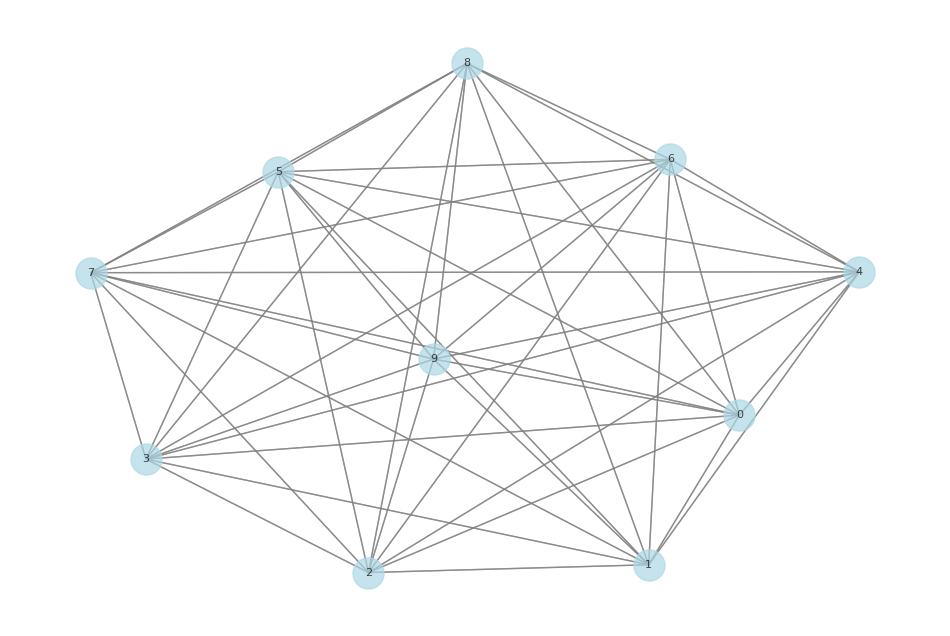

In [4]:
class CompleteGraph(GraphGenerator):
    def generate_graph(self, n):
        """
        Generates a complete graph with n nodes
        """
        self.graph = nx.complete_graph(n)


generator = CompleteGraph()
generator.generate_graph(10)
generator.visualise(node_labels=False)

## Weighted Graph

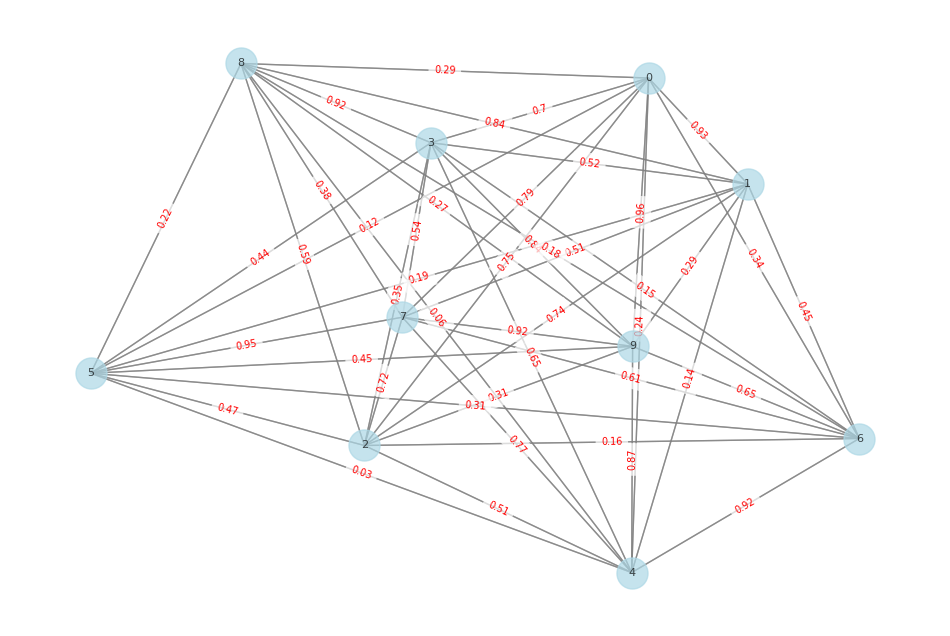

In [5]:
class WeightedGraph(GraphGenerator):
    def generate_graph(self, n):
        """
        Generates a complete graph with n nodes, with random weights
        """
        self.graph = nx.complete_graph(n)

        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = round(random.random(), 2)


generator = WeightedGraph()
generator.generate_graph(10)
generator.visualise(node_labels=False)

## Full r-ary Tree Graph

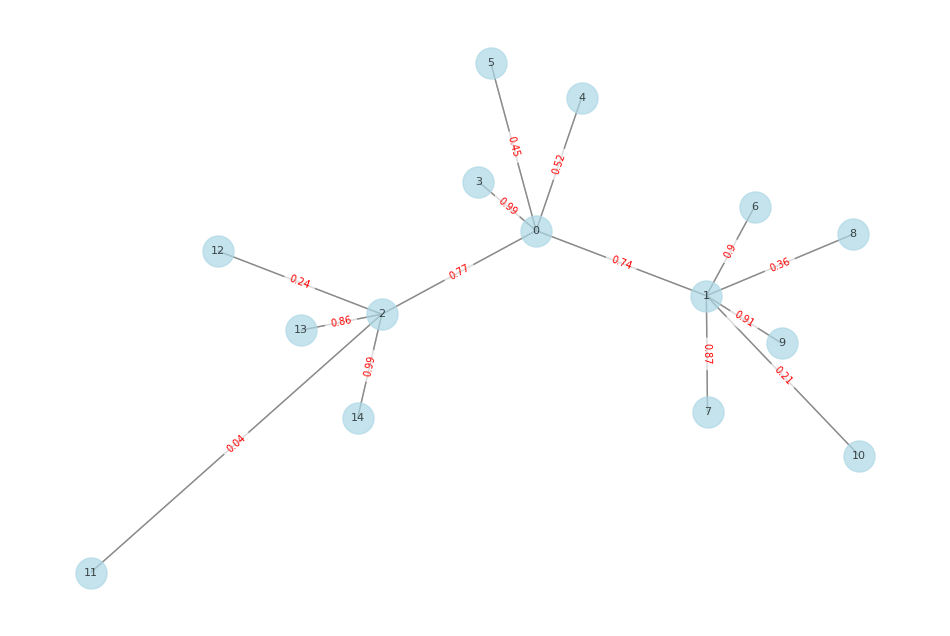

In [6]:
class FullRaryTree(GraphGenerator):
    def generate_graph(self, r, n):
        """
        Generates a full r-ary tree of n nodes with r branching factor, with random weights
        """
        self.graph = nx.full_rary_tree(r, n)

        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = round(random.random(), 2)


generator = FullRaryTree()
generator.generate_graph(5, 15)
generator.visualise(node_labels=False)

## Erdos Renyi Graph

In [7]:
class ErdosRenyiGraph(GraphGenerator):
    def generate_graph(self, n, p):
        """
        Generates a random graph, also known as an Erdős-Rényi graph or a binomial graph, with random weights
        """
        self.graph = nx.erdos_renyi_graph(
            n,
            p,
            directed=True,
            seed=np.random.default_rng(),
        )

        self.node_costs = {
            node: np.random.uniform(0.1, 25.0)
            for node in self.graph.nodes()
        }

        for node, cost in self.node_costs.items():
            self.graph.nodes[node]['node_costs'] = cost

        self.communities = self.louvain_communities()

        for i, community in enumerate(self.communities):
            for node in community:
                self.graph.nodes[node]['community'] = i


generator = ErdosRenyiGraph()
generator.generate_graph(200, 0.1)
generator.serialise(path_to_networks, 'erdos_renyi_200')

Graph serialised to networks\erdos_renyi_200.pkl


## Erdos Renyi Graph with Non-Uniform Node Costs

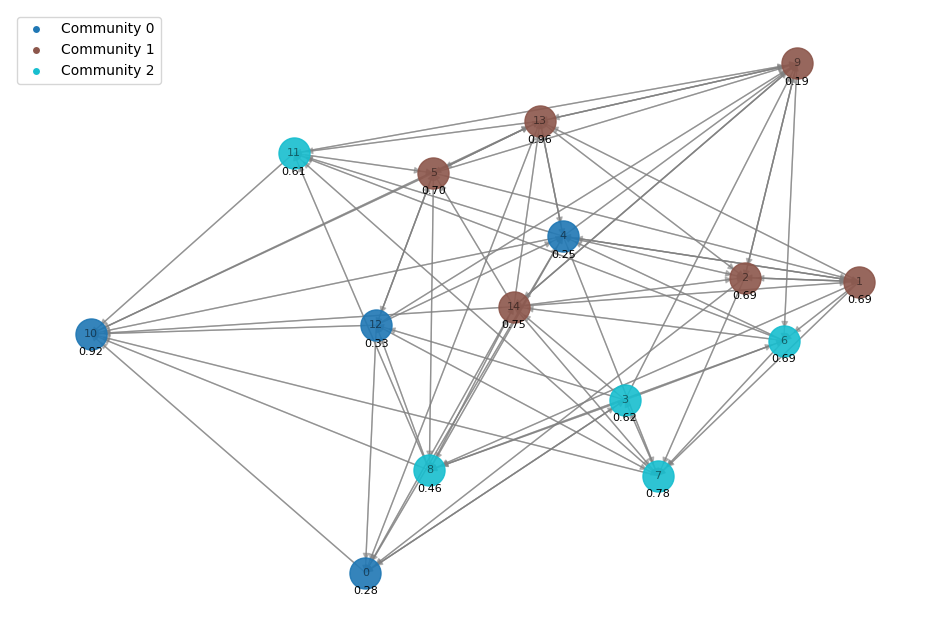

In [8]:
class NonUniformErdosRenyiGraph(GraphGenerator):
    def generate_graph(self, n, p):
        """
        Generates a random graph, also known as an Erdős-Rényi graph or a binomial graph, with random weights and non-uniform node costs.
        """
        self.graph = nx.erdos_renyi_graph(
            n,
            p,
            directed=True,
            seed=np.random.default_rng(),
        )

        self.node_costs = {
            node: np.random.uniform(0.1, 1.0)
            for node in self.graph.nodes()
        }

        self.communities = self.louvain_communities()

        for i, community in enumerate(self.communities):
            for node in community:
                self.graph.nodes[node]['community'] = i


generator = NonUniformErdosRenyiGraph()
generator.generate_graph(15, 0.3)
generator.visualise()

## Barbasi Albert Graph

In [29]:
class BarbasiAlbertGraph(GraphGenerator):
    def generate_graph(self, n, m, seed=42):
        """
        Generates a Barabási–Albert Graph with degree-normalized, noise-perturbed node costs.
        """
        if n <= m:
            raise ValueError("Barabási–Albert graph requires n > m.")

        rng = np.random.default_rng(seed)

        # Generate undirected BA graph, then convert to directed
        self.graph = nx.barabasi_albert_graph(n=n, m=m, seed=rng)
        self.graph = self.graph.to_directed()

        self.node_costs = {}

        deg_avg = np.mean([self.graph.degree(node) for node in self.graph.nodes()])
        for node in self.graph.nodes():
            cost = self.graph.degree(node) / deg_avg
            self.node_costs[node] = float(cost)
            self.graph.nodes[node]['node_costs'] = float(cost)

        # Detect communities
        self.communities = self.louvain_communities()
        for i, community in enumerate(self.communities):
            for node in community:
                self.graph.nodes[node]['community'] = i


generator = BarbasiAlbertGraph()
generator.generate_graph(10000, 7)
generator.serialise(path_to_networks, 'barbasi_albert_10000')

Graph serialised to networks\barbasi_albert_10000.pkl


## Stochastic Block Model

In [10]:
from sklearn.utils import check_random_state


class StochasticBlockGraph(GraphGenerator):
    def generate_graph(self, n, p_inter=0.005):
        """
        Generate a stochastic block model (SBM) graph with given intra- and inter-community probabilities.
        """
        rng = check_random_state(None)

        num_communities = 3
        sizes = [n // num_communities] * num_communities
        sizes[-1] += n - sum(sizes)

        q1, q2, q3 = 0.06, 0.03, 0.0

        probs = np.full((num_communities, num_communities), p_inter)
        np.fill_diagonal(probs, [q1, q2, q3])

        self.graph = nx.stochastic_block_model(sizes, probs, seed=rng)

        degrees = dict(self.graph.degree())
        self.node_costs = {
            node: 1.0 + 0.05 * degrees[node]
            for node in self.graph.nodes()
        }

        for node, cost in self.node_costs.items():
            self.graph.nodes[node]['node_costs'] = cost

        # Assign communities directly from block structure
        community_map = {}
        node_offset = 0
        self.communities = set()

        for i, size in enumerate(sizes):
            community = list(range(node_offset, node_offset + size))
            self.communities.add(i)
            for node in community:
                community_map[node] = i
            node_offset += size

        nx.set_node_attributes(self.graph, community_map, 'community')


generator = StochasticBlockGraph()
generator.generate_graph(n=500, p_inter=0.005)
generator.serialise(path_to_networks, 'sbm_500')

Graph serialised to networks\sbm_500.pkl


## Power Law Cluster Graph

In [19]:
class PowerLawClusterGraph(GraphGenerator):
    def generate_graph(self, n, m, p=0.3, alpha=0.5, beta=1.0, reciprocity=0.3, seed=42):
        """
        Generates a Power Law Cluster Graph with non-uniform node costs and community structures
        """
        rng = np.random.default_rng(seed)
        self.graph = nx.powerlaw_cluster_graph(
            n=n,
            m=m,
            p=p,
            seed=np.random.default_rng(),
        )

        self.graph = self.graph.to_directed()

        # Add reciprocal edges
        for u, v in list(self.graph.edges()):
            if not self.graph.has_edge(v, u) and rng.random() < reciprocity:
                self.graph.add_edge(v, u)

        # Cost as function of degree + noise
        noise = rng.normal(0, 1, size=n)
        self.node_costs = {
            node: max(alpha * self.graph.degree(node) + beta + noise[node], 0.1)
            for node in self.graph.nodes()
        }
        nx.set_node_attributes(self.graph, self.node_costs, 'node_costs')

        for u, v in self.graph.edges():
            self.graph[u][v]['weight'] = rng.uniform(0.1, 1.0)

        # Communities
        self.communities = self.louvain_communities()
        for i, community in enumerate(self.communities):
            for node in community:
                self.graph.nodes[node]['community'] = i


generator = PowerLawClusterGraph()
generator.generate_graph(5000, 4, 0.3)
generator.serialise(path_to_networks, 'plc_5000')

Graph serialised to networks\plc_5000.pkl


## Watts–Strogatz Graph

In [12]:
class WattsStrogatzGraph(GraphGenerator):
    def generate_graph(self, n, k, p):
        """
        Generates a WattsStrogatz Graph
        """
        self.graph = nx.watts_strogatz_graph(
            n=n,
            k=k,
            p=p,
        )

        self.node_costs = {
            node: random.uniform(0.1, 25.0)
            for node in self.graph.nodes()
        }

        for node, cost in self.node_costs.items():
            self.graph.nodes[node]['node_costs'] = cost

        self.communities = self.louvain_communities()

        for i, community in enumerate(self.communities):
            for node in community:
                self.graph.nodes[node]['community'] = i


generator = WattsStrogatzGraph()
generator.generate_graph(200, 4, 0.2)
generator.serialise(path_to_networks, 'watts_strogatz_200')

Graph serialised to networks\watts_strogatz_200.pkl
